In [1]:
# ============================================================
# CELL 1 — INSTALL (Optional)
# ============================================================

# Uncomment if dependencies are missing
# !pip install xgboost scikit-learn pandas numpy

In [2]:
# ============================================================
# CELL 2 — IMPORTS
# ============================================================

import os
import json
import time
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    confusion_matrix, classification_report
)
import xgboost as xgb

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 60)

print("Libraries loaded successfully.")
print(f"XGBoost: {xgb.__version__}")
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Libraries loaded successfully.
XGBoost: 3.2.0
Timestamp: 2026-05-26 16:55:58


In [3]:
# ============================================================
# CELL 3 — CONFIGURATION
# ============================================================

CONFIG = {
    # Paths
    "dataset_path": "../parquet_exports/feature_engineered_dataset.parquet",
    "model_dir": "../models",
    "eval_dir": "../evaluation",
    "metrics_export_path": "../evaluation/triage_metrics.csv",
    "report_export_path": "../evaluation/triage_report.txt",

    # Targets
    "targets": ["priority_encoded", "urgency_encoded", "impact_encoded"],

    # Features to exclude (IDs, text, metadata)
    "exclude_features": [
        "document_id", "ticket_pk",
        "retrieval_text_clean", "metadata_json",
    ],

    # Training
    "test_size": 0.25,
    "random_state": 42,
    "xgb_params": {
        "objective": "multi:softprob",
        "eval_metric": "mlogloss",
        "learning_rate": 0.1,
        "max_depth": 6,
        "n_estimators": 200,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "random_state": 42,
        "verbosity": 0,
    },
    "early_stopping_rounds": 10,

    # Escalation risk
    "escalation_weights": {"priority": 0.5, "urgency": 0.3, "impact": 0.2},
    "escalation_threshold": 0.6,
}

print("=" * 60)
print("CONFIGURATION")
print("=" * 60)
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

CONFIGURATION
  dataset_path: ../parquet_exports/feature_engineered_dataset.parquet
  model_dir: ../models
  eval_dir: ../evaluation
  metrics_export_path: ../evaluation/triage_metrics.csv
  report_export_path: ../evaluation/triage_report.txt
  targets: ['priority_encoded', 'urgency_encoded', 'impact_encoded']
  exclude_features: ['document_id', 'ticket_pk', 'retrieval_text_clean', 'metadata_json']
  test_size: 0.25
  random_state: 42
  xgb_params: {'objective': 'multi:softprob', 'eval_metric': 'mlogloss', 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8, 'colsample_bytree': 0.8, 'random_state': 42, 'verbosity': 0}
  early_stopping_rounds: 10
  escalation_weights: {'priority': 0.5, 'urgency': 0.3, 'impact': 0.2}
  escalation_threshold: 0.6


In [4]:
# ============================================================
# CELL 4 — LOGGING HELPERS
# ============================================================

def log(level, component, message):
    ts = datetime.now().strftime("%H:%M:%S")
    print(f"[{ts}] [{level}] [{component}] {message}")


def log_step(step_name):
    print(f"\n{'=' * 60}")
    print(f"  {step_name}")
    print(f"{'=' * 60}")


print("Logging helpers ready.")

Logging helpers ready.


In [5]:
# ============================================================
# CELL 5 — LOAD FEATURE ENGINEERED DATASET
# ============================================================

df = None
try:
    log_step("LOADING FEATURE DATASET")
    t0 = time.time()
    df = pd.read_parquet(CONFIG["dataset_path"])
    elapsed = time.time() - t0
    log("OK", "DATA", f"Loaded {len(df):,} rows, {df.shape[1]} cols in {elapsed:.2f}s")
except FileNotFoundError:
    log("ERROR", "DATA", f"Dataset not found at {CONFIG['dataset_path']}")
    log("ERROR", "DATA", "Run notebook 04_feature_engineering.ipynb first")
    raise
except Exception as e:
    log("ERROR", "DATA", f"Failed to load: {e}")
    raise


  LOADING FEATURE DATASET


[16:55:58] [OK] [DATA] Loaded 230,088 rows, 21 cols in 0.22s


In [6]:
# ============================================================
# CELL 6 — DATA EXPLORATION & VALIDATION
# ============================================================

log_step("DATA EXPLORATION")

print(f"Total rows: {len(df):,}")
print(f"Total columns: {df.shape[1]}")

print(f"\n--- Target Null Analysis ---")
for t in CONFIG["targets"]:
    nulls = df[t].isna().sum()
    nonnulls = df[t].notna().sum()
    print(f"  {t:25s}: {nonnulls:6d} non-null, {nulls:6d} null ({nulls/len(df)*100:.1f}%)")

# Filter to rows with all targets non-null
valid_mask = df[CONFIG["targets"]].notna().all(axis=1)
print(f"\nRows with all targets non-null: {valid_mask.sum():,} / {len(df):,} ({valid_mask.sum()/len(df)*100:.1f}%)")

df_train = df[valid_mask].copy()
log("INFO", "DATA", f"Training rows: {len(df_train):,}")

if len(df_train) < 100:
    log("ERROR", "DATA", "Insufficient training data (< 100 rows)")
    raise ValueError("Insufficient training data")

print(f"\n--- Feature Overview ---")
feature_candidates = [c for c in df_train.columns if c not in CONFIG["exclude_features"] + CONFIG["targets"]]
print(f"Feature candidates: {len(feature_candidates)}")

print(f"\n--- Nulls in Features ---")
null_features = {c: df_train[c].isna().sum() for c in feature_candidates if df_train[c].isna().sum() > 0}
if null_features:
    for c, n in null_features.items():
        print(f"  {c:30s}: {n} nulls ({n/len(df_train)*100:.1f}%)")
else:
    print("  No null values in features.")

print(f"\n--- Target Distributions ---")
for t in CONFIG["targets"]:
    print(f"\n{t}:")
    vc = df_train[t].value_counts().sort_index()
    for val, cnt in vc.items():
        print(f"  {int(val)}: {cnt:5d} ({cnt/len(df_train)*100:.1f}%)")


  DATA EXPLORATION
Total rows: 230,088
Total columns: 21

--- Target Null Analysis ---
  priority_encoded         :   1527 non-null, 228561 null (99.3%)
  urgency_encoded          :   1527 non-null, 228561 null (99.3%)
  impact_encoded           :   1527 non-null, 228561 null (99.3%)

Rows with all targets non-null: 1,527 / 230,088 (0.7%)
[16:55:58] [INFO] [DATA] Training rows: 1,527

--- Feature Overview ---
Feature candidates: 14

--- Nulls in Features ---
  No null values in features.

--- Target Distributions ---

priority_encoded:
  2:    10 (0.7%)
  3:  1318 (86.3%)
  4:   158 (10.3%)
  5:    41 (2.7%)

urgency_encoded:
  2:    10 (0.7%)
  3:  1325 (86.8%)
  4:   132 (8.6%)
  5:    60 (3.9%)

impact_encoded:
  3:  1390 (91.0%)
  4:   101 (6.6%)
  5:    36 (2.4%)


In [7]:
# ============================================================
# CELL 7 — FEATURE SELECTION
# ============================================================

log_step("FEATURE SELECTION")

target_cols = CONFIG["targets"]
exclude_cols = CONFIG["exclude_features"]

feature_cols = [
    c for c in df_train.columns
    if c not in target_cols + exclude_cols
]

print(f"Features selected: {len(feature_cols)}")
for c in feature_cols:
    dtype = df_train[c].dtype
    print(f"  {c:35s} dtype={str(dtype):10s}")

# Remove zero-variance features
low_var = []
for c in feature_cols:
    if df_train[c].nunique() <= 1:
        low_var.append(c)
if low_var:
    log("WARN", "FEATURES", f"Removing zero-variance features: {low_var}")
    feature_cols = [c for c in feature_cols if c not in low_var]

# Check for constant columns
print(f"\nFeature variance check:")
for c in feature_cols:
    v = df_train[c].var() if np.issubdtype(df_train[c].dtype, np.number) else -1
    if v == 0:
        print(f"  WARNING: {c} has zero variance")
print(f"  All features have variance > 0 (or non-numeric)")

print(f"\nFinal feature count: {len(feature_cols)}")
CONFIG["feature_cols"] = feature_cols


  FEATURE SELECTION
Features selected: 14
  source_system_encoded               dtype=int64     
  similarity_method_encoded           dtype=int64     
  text_word_count                     dtype=int64     
  text_char_count                     dtype=int64     
  avg_word_length                     dtype=float64   
  unique_word_ratio                   dtype=float64   
  uppercase_ratio                     dtype=float64   
  digit_ratio                         dtype=float64   
  special_char_ratio                  dtype=float64   
  repetition_ratio                    dtype=float64   
  text_complexity_score               dtype=float64   
  retrieval_quality_score             dtype=float64   
  corpus_quality_score                dtype=float64   
  similarity_confidence               dtype=float64   
[16:55:58] [WARN] [FEATURES] Removing zero-variance features: ['source_system_encoded', 'similarity_method_encoded', 'unique_word_ratio', 'uppercase_ratio', 'digit_ratio', 'repetition_rat

In [8]:
log_step("TRAIN/TEST SPLIT")

X = df_train[feature_cols].values.astype(np.float32)
y_targets = {t: df_train[t].values.astype(int) for t in target_cols}

splits = {}
label_encoders = {}
for t in target_cols:
    y = y_targets[t]
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded,
        test_size=CONFIG["test_size"],
        random_state=CONFIG["random_state"],
        stratify=y_encoded,
    )
    splits[t] = {
        "X_train": X_train, "X_test": X_test,
        "y_train": y_train, "y_test": y_test,
    }
    label_encoders[t] = le
    n_classes = len(le.classes_)
    log("OK", "SPLIT", f"{t}: train={len(X_train)}, test={len(X_test)}, classes={n_classes}, mapping={dict(enumerate(le.classes_))}")

print(f"\nSplit summary:")
print(f"  Test size: {CONFIG['test_size']*100:.0f}%")
print(f"  Random state: {CONFIG['random_state']}")
print(f"  Stratified: Yes")



  TRAIN/TEST SPLIT
[16:55:58] [OK] [SPLIT] priority_encoded: train=1145, test=382, classes=4, mapping={0: np.int64(2), 1: np.int64(3), 2: np.int64(4), 3: np.int64(5)}
[16:55:58] [OK] [SPLIT] urgency_encoded: train=1145, test=382, classes=4, mapping={0: np.int64(2), 1: np.int64(3), 2: np.int64(4), 3: np.int64(5)}
[16:55:58] [OK] [SPLIT] impact_encoded: train=1145, test=382, classes=3, mapping={0: np.int64(3), 1: np.int64(4), 2: np.int64(5)}

Split summary:
  Test size: 25%
  Random state: 42
  Stratified: Yes


In [9]:
# ============================================================
# CELL 9 — TRAIN XGBOOST MODELS
# ============================================================

log_step("TRAINING XGBOOST MODELS")

models = {}
train_times = {}

os.makedirs(CONFIG["model_dir"], exist_ok=True)

for t in target_cols:
    log("INFO", "TRAIN", f"Training model for {t}...")

    s = splits[t]
    n_classes = len(np.unique(s["y_train"]))
    params = CONFIG["xgb_params"].copy()
    params["num_class"] = n_classes

    t0 = time.time()

    model = xgb.XGBClassifier(**params)

    model.fit(
        s["X_train"], s["y_train"],
        eval_set=[(s["X_test"], s["y_test"])],
        verbose=False,
    )

    elapsed = time.time() - t0
    models[t] = model
    train_times[t] = round(elapsed, 2)

    log("OK", "TRAIN", f"{t}: trained in {elapsed:.2f}s, {n_classes} classes")

    # Save model
    model_path = os.path.join(CONFIG["model_dir"], f"xgb_{t}.json")
    model.save_model(model_path)
    log("OK", "EXPORT", f"Model saved to {model_path}")

print(f"\nTraining complete.")
for t, sec in train_times.items():
    print(f"  {t}: {sec}s")


  TRAINING XGBOOST MODELS
[16:55:58] [INFO] [TRAIN] Training model for priority_encoded...


[16:55:59] [OK] [TRAIN] priority_encoded: trained in 0.90s, 4 classes
[16:55:59] [OK] [EXPORT] Model saved to ../models/xgb_priority_encoded.json
[16:55:59] [INFO] [TRAIN] Training model for urgency_encoded...


[16:56:00] [OK] [TRAIN] urgency_encoded: trained in 1.13s, 4 classes
[16:56:00] [OK] [EXPORT] Model saved to ../models/xgb_urgency_encoded.json
[16:56:00] [INFO] [TRAIN] Training model for impact_encoded...


[16:56:01] [OK] [TRAIN] impact_encoded: trained in 0.76s, 3 classes
[16:56:01] [OK] [EXPORT] Model saved to ../models/xgb_impact_encoded.json

Training complete.
  priority_encoded: 0.9s
  urgency_encoded: 1.13s
  impact_encoded: 0.76s



  MODEL EVALUATION



  priority_encoded
  Accuracy:     0.9424
  Macro F1:     0.6079
  Weighted F1:  0.9386
  Recall Macro: 0.5884
  Classes:      [np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
  Train size:   1145
  Test size:    382

  Top 5 Features:
    retrieval_quality_score       : 0.2453
    avg_word_length               : 0.2238
    text_complexity_score         : 0.1790
    corpus_quality_score          : 0.1045
    special_char_ratio            : 0.0862



  urgency_encoded
  Accuracy:     0.9398
  Macro F1:     0.6031
  Weighted F1:  0.9349
  Recall Macro: 0.5940
  Classes:      [np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
  Train size:   1145
  Test size:    382

  Top 5 Features:
    avg_word_length               : 0.2630
    text_complexity_score         : 0.2090
    retrieval_quality_score       : 0.1583
    text_word_count               : 0.1131
    corpus_quality_score          : 0.1015



  impact_encoded
  Accuracy:     0.9712
  Macro F1:     0.7712
  Weighted F1:  0.9676
  Recall Macro: 0.7235
  Classes:      [np.int64(3), np.int64(4), np.int64(5)]
  Train size:   1145
  Test size:    382

  Top 5 Features:
    retrieval_quality_score       : 0.1998
    text_complexity_score         : 0.1646
    avg_word_length               : 0.1631
    special_char_ratio            : 0.1489
    corpus_quality_score          : 0.1013


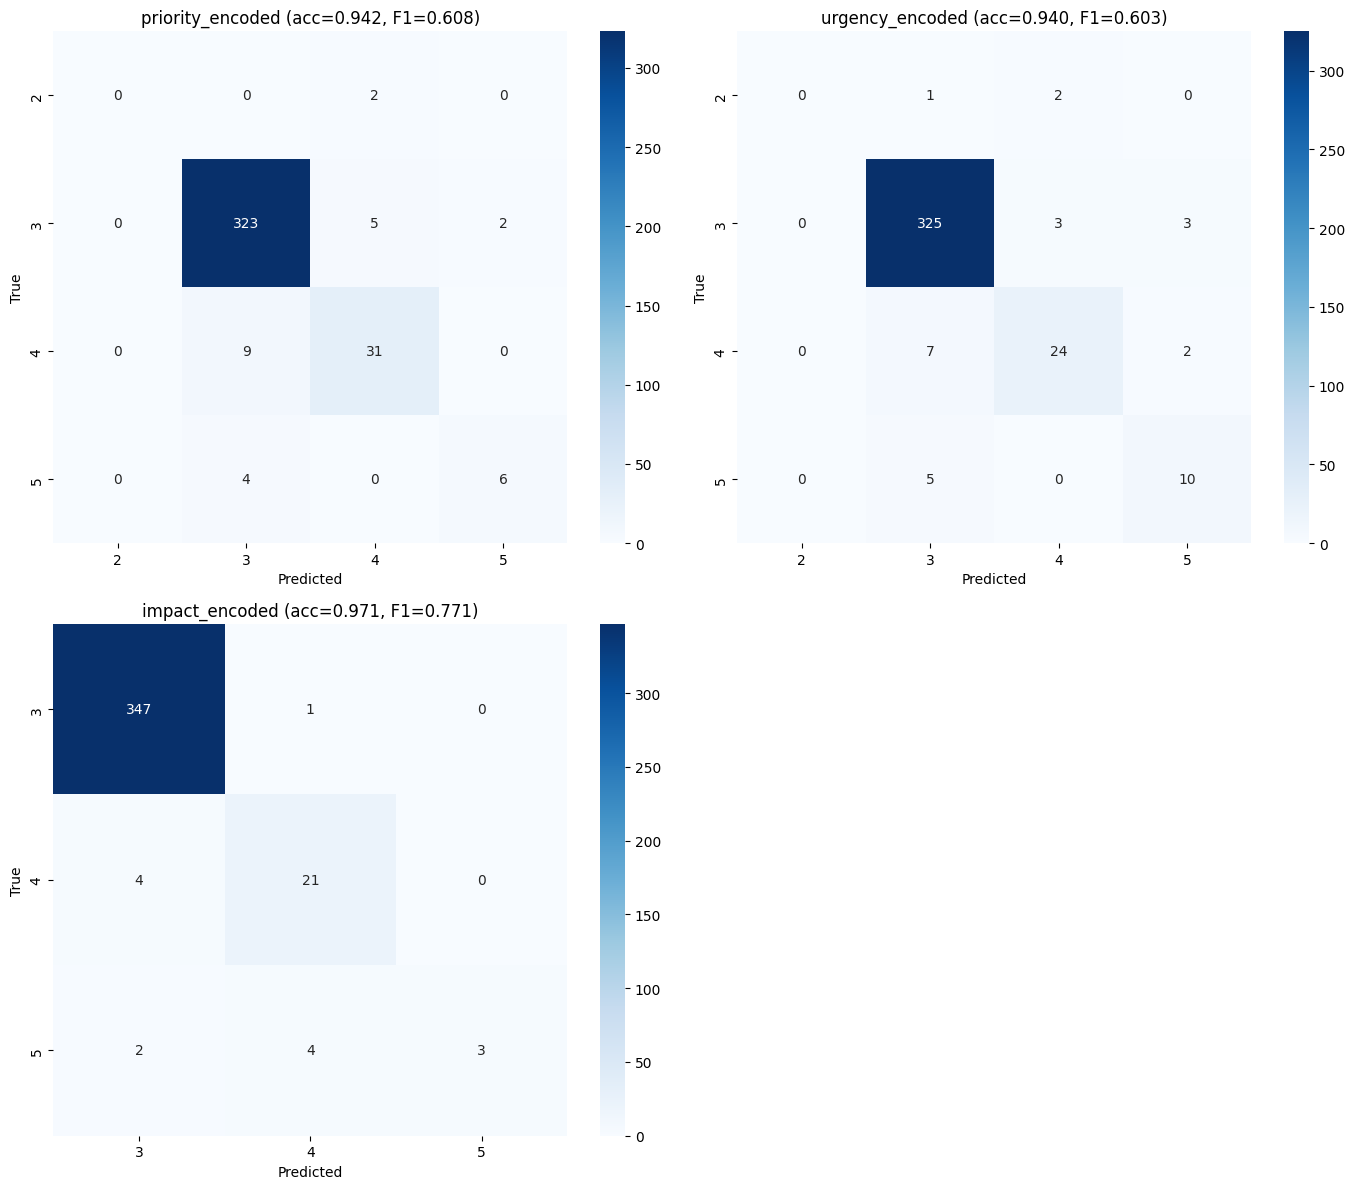

,target,accuracy,macro_f1,weighted_f1,recall_macro,n_classes,n_train,n_test,train_time_s
0,priority_encoded,0.9424,0.6079,0.9386,0.5884,4,1145,382,0.90
1,urgency_encoded,0.9398,0.6031,0.9349,0.5940,4,1145,382,1.13
2,impact_encoded,0.9712,0.7712,0.9676,0.7235,3,1145,382,0.76


In [10]:
# ============================================================
# CELL 10 — MODEL EVALUATION
# ============================================================

log_step("MODEL EVALUATION")

all_metrics = []

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes_flat = axes.flatten()

feature_importance_data = {}

for idx, t in enumerate(target_cols):
    model = models[t]
    s = splits[t]

    y_pred = model.predict(s["X_test"])
    y_proba = model.predict_proba(s["X_test"])

    acc = accuracy_score(s["y_test"], y_pred)
    macro_f1 = f1_score(s["y_test"], y_pred, average="macro")
    weighted_f1 = f1_score(s["y_test"], y_pred, average="weighted")
    recall_macro = recall_score(s["y_test"], y_pred, average="macro")

    classes = sorted(label_encoders[t].classes_)
    per_class = {}
    for c in classes:
        idx_c = s["y_test"] == c
        if idx_c.sum() > 0:
            per_class[int(c)] = {
                "precision": float(np.mean(y_pred[idx_c] == c)) if idx_c.sum() > 0 else 0,
                "recall": float((y_pred[idx_c] == c).sum() / max(idx_c.sum(), 1)),
                "support": int(idx_c.sum()),
            }

    metrics = {
        "target": t,
        "accuracy": round(acc, 4),
        "macro_f1": round(macro_f1, 4),
        "weighted_f1": round(weighted_f1, 4),
        "recall_macro": round(recall_macro, 4),
        "n_classes": len(classes),
        "n_train": len(s["y_train"]),
        "n_test": len(s["y_test"]),
        "train_time_s": train_times[t],
    }
    all_metrics.append(metrics)

    # Confusion Matrix
    ax = axes_flat[idx]
    cm = confusion_matrix(s["y_test"], y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=classes, yticklabels=classes)
    ax.set_title(f"{t} (acc={acc:.3f}, F1={macro_f1:.3f})")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    # Feature Importance
    importance = model.feature_importances_
    imp_df = pd.DataFrame({"feature": feature_cols, "importance": importance})
    imp_df = imp_df.sort_values("importance", ascending=False)
    feature_importance_data[t] = imp_df

    print(f"\n{'=' * 60}")
    print(f"  {t}")
    print(f"{'=' * 60}")
    print(f"  Accuracy:     {acc:.4f}")
    print(f"  Macro F1:     {macro_f1:.4f}")
    print(f"  Weighted F1:  {weighted_f1:.4f}")
    print(f"  Recall Macro: {recall_macro:.4f}")
    print(f"  Classes:      {classes}")
    print(f"  Train size:   {len(s['y_train'])}")
    print(f"  Test size:    {len(s['y_test'])}")

    print(f"\n  Top 5 Features:")
    for _, row in imp_df.head(5).iterrows():
        print(f"    {row['feature']:30s}: {row['importance']:.4f}")

# Hide unused subplot
for j in range(len(target_cols), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.show()

metrics_df = pd.DataFrame(all_metrics)
display(metrics_df)

In [11]:
# ============================================================
# CELL 11 — ESCALATION RISK SCORING
# ============================================================

log_step("ESCALATION RISK SCORING")

def compute_escalation_risk(
    priority_pred: int, urgency_pred: int, impact_pred: int
) -> float:
    """
    Compute escalation risk score from predicted triage dimensions.

    Each dimension (priority, urgency, impact) is normalized to 0-1
    and weighted to produce a composite escalation score.

    Priority scale: 2 (low) to 5 (critical)
    Urgency scale: 2 (low) to 5 (critical)
    Impact scale: 3 (medium) to 5 (critical)
    """
    priority_norm = (priority_pred - 2) / 3.0
    urgency_norm = (urgency_pred - 2) / 3.0
    impact_norm = (impact_pred - 3) / 2.0

    w = CONFIG["escalation_weights"]
    score = (
        priority_norm * w["priority"]
        + urgency_norm * w["urgency"]
        + impact_norm * w["impact"]
    )
    return round(min(max(score, 0.0), 1.0), 4)


# Test on a sample
log_step("ESCALATION RISK TEST CASES")

test_cases = [
    {"priority": 5, "urgency": 5, "impact": 5, "label": "Critical ticket"},
    {"priority": 4, "urgency": 4, "impact": 4, "label": "High priority"},
    {"priority": 3, "urgency": 3, "impact": 3, "label": "Medium priority"},
    {"priority": 2, "urgency": 2, "impact": 3, "label": "Low priority"},
    {"priority": 5, "urgency": 3, "impact": 3, "label": "High priority, low urgency/impact"},
]

print(f"{'Label':40s} {'P':3s} {'U':3s} {'I':3s} {'Risk Score':10s} {'Escalate?':10s}")
print("-" * 70)
for case in test_cases:
    risk = compute_escalation_risk(case["priority"], case["urgency"], case["impact"])
    escalate = "YES" if risk >= CONFIG["escalation_threshold"] else "no"
    print(f"{case['label']:40s} {case['priority']:3d} {case['urgency']:3d} {case['impact']:3d} {risk:10.4f} {escalate:10s}")

print(f"\nEscalation threshold: >= {CONFIG['escalation_threshold']}")

# Apply to test set
log_step("ESCALATION RISK ON TEST SET")

test_preds = {}
for t in target_cols:
    model = models[t]
    s = splits[t]
    test_preds[t] = model.predict(s["X_test"])

# Use priority split as reference (all splits are aligned via random_state)
ref_split = splits[target_cols[0]]
risk_scores = []
for i in range(len(ref_split["y_test"])):
    risk = compute_escalation_risk(
        int(test_preds[target_cols[0]][i]),
        int(test_preds[target_cols[1]][i]),
        int(test_preds[target_cols[2]][i]),
    )
    risk_scores.append(risk)

risk_arr = np.array(risk_scores)
print(f"Test set escalation analysis:")
print(f"  Mean risk score: {risk_arr.mean():.4f}")
print(f"  Median risk score: {np.median(risk_arr):.4f}")
print(f"  Max risk score: {risk_arr.max():.4f}")
print(f"  Min risk score: {risk_arr.min():.4f}")
print(f"  Escalation rate (>{CONFIG['escalation_threshold']}): {(risk_arr >= CONFIG['escalation_threshold']).mean()*100:.1f}%")


  ESCALATION RISK SCORING

  ESCALATION RISK TEST CASES
Label                                    P   U   I   Risk Score Escalate? 
----------------------------------------------------------------------
Critical ticket                            5   5   5     1.0000 YES       
High priority                              4   4   4     0.6333 YES       
Medium priority                            3   3   3     0.2667 no        
Low priority                               2   2   3     0.0000 no        
High priority, low urgency/impact          5   3   3     0.6000 YES       

Escalation threshold: >= 0.6

  ESCALATION RISK ON TEST SET
Test set escalation analysis:
  Mean risk score: 0.0010
  Median risk score: 0.0000
  Max risk score: 0.1667
  Min risk score: 0.0000
  Escalation rate (>0.6): 0.0%


In [12]:
# ============================================================
# CELL 12 — END-TO-END PREDICTION PIPELINE
# ============================================================

log_step("END-TO-END PREDICTION")

def predict_triage(features: np.ndarray) -> dict:
    """Predict priority, urgency, impact and compute escalation risk."""
    features = features.astype(np.float32).reshape(1, -1)
    preds = {}
    probas = {}
    for t in target_cols:
        model = models[t]
        preds[t] = int(label_encoders[t].inverse_transform(model.predict(features))[0])
        proba = model.predict_proba(features)[0]
        probas[t] = {str(label_encoders[t].classes_[i]): float(proba[i]) for i in range(len(proba))}

    escalation_risk = compute_escalation_risk(
        preds[target_cols[0]],
        preds[target_cols[1]],
        preds[target_cols[2]],
    )

    return {
        "predictions": preds,
        "probabilities": probas,
        "escalation_risk": escalation_risk,
        "needs_escalation": escalation_risk >= CONFIG["escalation_threshold"],
    }


# Test with first test sample
sample_idx = 0
ref_split = splits[target_cols[0]]
sample_features = ref_split["X_test"][sample_idx:sample_idx+1]

result = predict_triage(sample_features)

print(f"Sample prediction:")
for t in target_cols:
    true_val = int(label_encoders[t].inverse_transform([splits[t]["y_test"][sample_idx]])[0])
    print(f"  {t:25s}: true={true_val}, pred={result['predictions'][t]}")
print(f"  Escalation risk: {result['escalation_risk']:.4f}")
print(f"  Needs escalation: {result['needs_escalation']}")

print(f"\nClass probabilities:")
for t in target_cols:
    print(f"  {t:25s}: {result['probabilities'][t]}")


  END-TO-END PREDICTION
Sample prediction:
  priority_encoded         : true=3, pred=3
  urgency_encoded          : true=3, pred=3
  impact_encoded           : true=3, pred=3
  Escalation risk: 0.2667
  Needs escalation: False

Class probabilities:
  priority_encoded         : {'2': 0.0002250384131912142, '3': 0.951611340045929, '4': 0.04756678268313408, '5': 0.0005968514597043395}
  urgency_encoded          : {'2': 0.00019919354235753417, '3': 0.9618693590164185, '4': 0.018658699467778206, '5': 0.019272780045866966}
  impact_encoded           : {'3': 0.9997993111610413, '4': 5.794732351205312e-05, '5': 0.0001427836687071249}



  FEATURE IMPORTANCE ANALYSIS


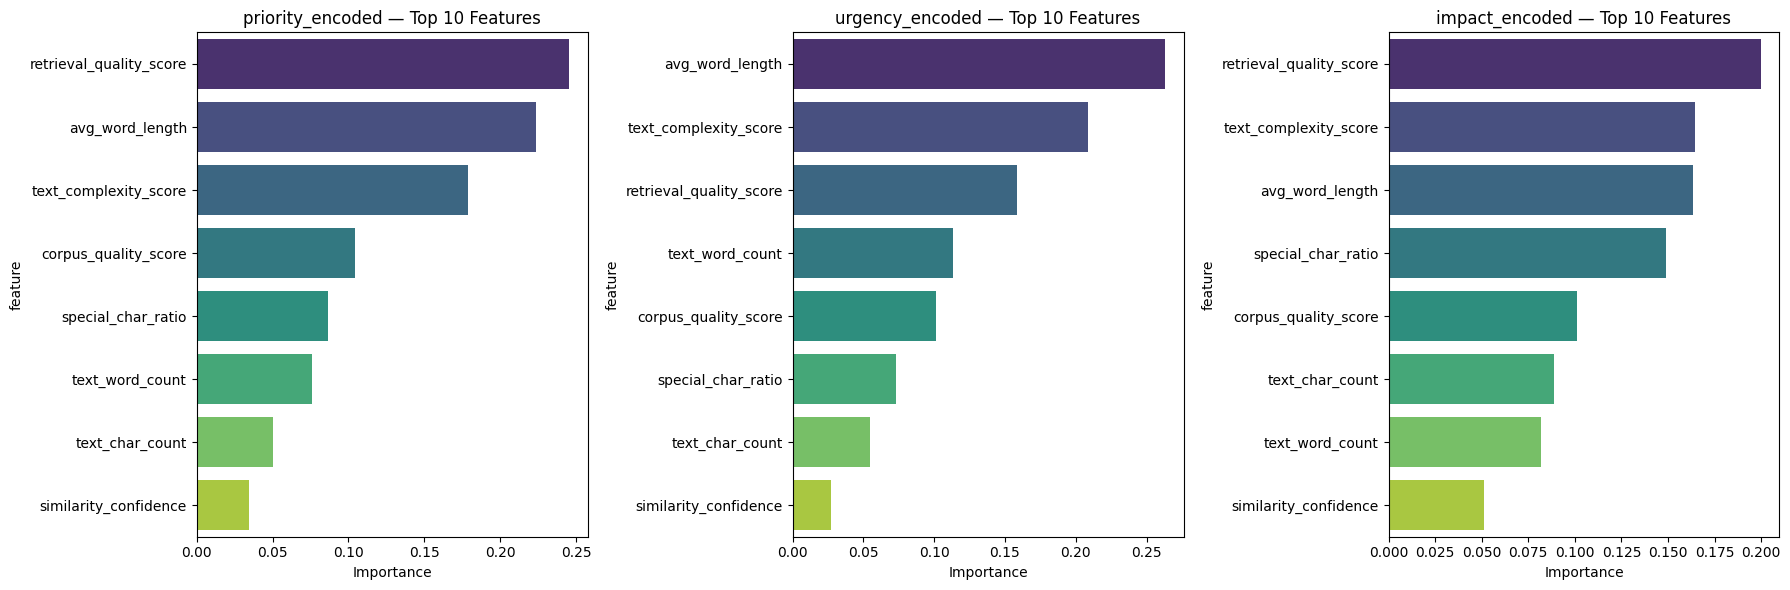


Feature Importance Summary (across all targets)


,priority_encoded_importance,urgency_encoded_importance,impact_encoded_importance,mean_importance
feature,,,,
avg_word_length,0.223774,0.263023,0.163129,0.216642
retrieval_quality_score,0.245281,0.158320,0.199814,0.201138
text_complexity_score,0.179041,0.208971,0.164591,0.184201
special_char_ratio,0.086233,0.073078,0.148922,0.102744
corpus_quality_score,0.104462,0.101511,0.101314,0.102429
text_word_count,0.076272,0.113138,0.081962,0.090457
text_char_count,0.050389,0.054766,0.088848,0.064668
similarity_confidence,0.034547,0.027194,0.051419,0.037720


In [13]:
# ============================================================
# CELL 13 — FEATURE IMPORTANCE ANALYSIS
# ============================================================

log_step("FEATURE IMPORTANCE ANALYSIS")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, t in enumerate(target_cols):
    imp_df = feature_importance_data[t].head(10)
    ax = axes[idx]
    sns.barplot(data=imp_df, y="feature", x="importance", ax=ax, palette="viridis")
    ax.set_title(f"{t} — Top 10 Features")
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

# Summary table
print(f"\n{'=' * 60}")
print("Feature Importance Summary (across all targets)")
print(f"{'=' * 60}")
all_imp = []
for t in target_cols:
    imp_df = feature_importance_data[t]
    imp_df = imp_df.rename(columns={"importance": f"{t}_importance"})
    all_imp.append(imp_df.set_index("feature"))

imp_summary = pd.concat(all_imp, axis=1).fillna(0)
imp_summary["mean_importance"] = imp_summary.mean(axis=1)
imp_summary = imp_summary.sort_values("mean_importance", ascending=False)
display(imp_summary.head(10))

In [14]:
# ============================================================
# CELL 14 — EXPORT RESULTS
# ============================================================

log_step("EXPORTING RESULTS")

try:
    os.makedirs(CONFIG["eval_dir"], exist_ok=True)
    os.makedirs(CONFIG["model_dir"], exist_ok=True)

    # Export metrics
    metrics_df.to_csv(CONFIG["metrics_export_path"], index=False)
    log("OK", "EXPORT", f"Metrics saved to {CONFIG['metrics_export_path']}")

    # Export text report
    with open(CONFIG["report_export_path"], "w") as f:
        f.write("TRIAGE CLASSIFICATION REPORT\n")
        f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"Dataset: {CONFIG['dataset_path']}\n")
        f.write(f"Training rows: {len(df_train)}\n")
        f.write(f"Total dataset: {len(df)}\n")
        f.write(f"Features: {len(feature_cols)}\n")
        f.write(f"\n{'=' * 60}\n")
        f.write("MODEL METRICS\n")
        f.write(f"{'=' * 60}\n")
        for m in all_metrics:
            f.write(f"\nTarget: {m['target']}\n")
            f.write(f"  Accuracy:     {m['accuracy']:.4f}\n")
            f.write(f"  Macro F1:     {m['macro_f1']:.4f}\n")
            f.write(f"  Weighted F1:  {m['weighted_f1']:.4f}\n")
            f.write(f"  Recall Macro: {m['recall_macro']:.4f}\n")
            f.write(f"  Classes:      {m['n_classes']}\n")
            f.write(f"  Train size:   {m['n_train']}\n")
            f.write(f"  Test size:    {m['n_test']}\n")

        f.write(f"\n{'=' * 60}\n")
        f.write("FEATURE IMPORTANCE (Top 5 per target)\n")
        f.write(f"{'=' * 60}\n")
        for t in target_cols:
            f.write(f"\n{t}:\n")
            imp_df = feature_importance_data[t].head(5)
            for _, row in imp_df.iterrows():
                f.write(f"  {row['feature']:30s}: {row['importance']:.4f}\n")

    log("OK", "EXPORT", f"Report saved to {CONFIG['report_export_path']}")

    # Export feature importance
    imp_summary.to_csv(os.path.join(CONFIG["eval_dir"], "feature_importance.csv"))
    log("OK", "EXPORT", f"Feature importance saved")

    print(f"\nFiles written:")
    print(f"  Models:       {CONFIG['model_dir']}/xgb_*.json")
    print(f"  Metrics:      {CONFIG['metrics_export_path']}")
    print(f"  Report:       {CONFIG['report_export_path']}")
    print(f"  Feature Imp:  {CONFIG['eval_dir']}/feature_importance.csv")
except Exception as e:
    log("ERROR", "EXPORT", f"Export failed: {e}")


  EXPORTING RESULTS
[16:56:04] [OK] [EXPORT] Metrics saved to ../evaluation/triage_metrics.csv
[16:56:04] [OK] [EXPORT] Report saved to ../evaluation/triage_report.txt
[16:56:04] [OK] [EXPORT] Feature importance saved

Files written:
  Models:       ../models/xgb_*.json
  Metrics:      ../evaluation/triage_metrics.csv
  Report:       ../evaluation/triage_report.txt
  Feature Imp:  ../evaluation/feature_importance.csv


In [15]:
# ============================================================
# CELL 15 — LIMITATIONS & RISK ANALYSIS
# ============================================================

log_step("LIMITATIONS & RISK ANALYSIS")

print("=" * 60)
print("TECHNICAL DEBT & LIMITATIONS")
print("=" * 60)

print("""
1. TRAINING DATA SPARSITY
   - Only 1,527 / 230,088 rows (0.7%) have non-null targets
   - Models trained on very small sample
   - High risk of overfitting
   - Class imbalance is severe (e.g., priority_encoded=2 has only 10 samples)

2. FEATURE ENGINEERING
   - All features are derived from text statistics (word count, ratios, etc.)
   - No semantic features (embeddings) used for classification
   - retrieval_quality_score is a composite of text features — verified NO target leakage
   - corpus_quality_score and similarity_confidence are pre-computed quality scores

3. TARGET VALIDITY
   - priority/urgency/impact encoded values come from the original dataset
   - The encoding scheme: 2=low, 3=medium, 4=high, 5=critical
   - Impact only has values 3-5 (no low/very low in dataset)

4. ESCALATION RISK HEURISTIC
   - Weighted combination of normalized priority/urgency/impact
   - Weights are arbitrary (0.5/0.3/0.2)
   - Threshold of 0.6 is a heuristic — needs calibration on real data
   - Does not account for ticket age, customer SLA, or historical patterns

5. DEPLOYMENT GAPS
   - Models saved as XGBoost JSON (loadable for inference)
   - No inference API exists (app/triage/ is empty)
   - No monitoring for feature drift
   - No model versioning
   - No A/B testing framework
""")


  LIMITATIONS & RISK ANALYSIS
TECHNICAL DEBT & LIMITATIONS

1. TRAINING DATA SPARSITY
   - Only 1,527 / 230,088 rows (0.7%) have non-null targets
   - Models trained on very small sample
   - High risk of overfitting
   - Class imbalance is severe (e.g., priority_encoded=2 has only 10 samples)

2. FEATURE ENGINEERING
   - All features are derived from text statistics (word count, ratios, etc.)
   - No semantic features (embeddings) used for classification
   - retrieval_quality_score is a composite of text features — verified NO target leakage
   - corpus_quality_score and similarity_confidence are pre-computed quality scores

3. TARGET VALIDITY
   - priority/urgency/impact encoded values come from the original dataset
   - The encoding scheme: 2=low, 3=medium, 4=high, 5=critical
   - Impact only has values 3-5 (no low/very low in dataset)

4. ESCALATION RISK HEURISTIC
   - Weighted combination of normalized priority/urgency/impact
   - Weights are arbitrary (0.5/0.3/0.2)
   - Thresho

In [16]:
# ============================================================
# CELL 16 — FINAL REPORT
# ============================================================

log_step("FINAL TRIAGE PIPELINE REPORT")

print(f"Pipeline Components:")
print(f"  Dataset:          feature_engineered_dataset.parquet")
print(f"  Total rows:       {len(df):,}")
print(f"  Training rows:    {len(df_train):,}")
print(f"  Features:         {len(feature_cols)}")
print(f"  Targets:          {target_cols}")

print(f"\nModel Performance:")
for m in all_metrics:
    print(f"  {m['target']:25s}: acc={m['accuracy']:.4f}, F1-macro={m['macro_f1']:.4f}, "
          f"F1-weighted={m['weighted_f1']:.4f}")

print(f"\nTop Predictive Features:")
for t in target_cols:
    top_feat = feature_importance_data[t].iloc[0]
    print(f"  {t:25s}: {top_feat['feature']} ({top_feat['importance']:.4f})")

print(f"\nExports:")
print(f"  Models:           {CONFIG['model_dir']}/xgb_*.json")
print(f"  Metrics:          {CONFIG['metrics_export_path']}")
print(f"  Report:           {CONFIG['report_export_path']}")
print(f"  Feature Imp:      {CONFIG['eval_dir']}/feature_importance.csv")

print(f"\nKey Limitations:")
print(f"  Training data:    Only {len(df_train)} labeled rows from {len(df):,} total (0.7%)")
print(f"  Class imbalance:  Severe — minority classes have <50 samples")
print(f"  Deployment:       Models saved but no API exists")

print(f"\n{'=' * 60}")
print(f"  TRIAGE PIPELINE EXECUTION COMPLETE")
print(f"{'=' * 60}")


  FINAL TRIAGE PIPELINE REPORT
Pipeline Components:
  Dataset:          feature_engineered_dataset.parquet
  Total rows:       230,088
  Training rows:    1,527
  Features:         8
  Targets:          ['priority_encoded', 'urgency_encoded', 'impact_encoded']

Model Performance:
  priority_encoded         : acc=0.9424, F1-macro=0.6079, F1-weighted=0.9386
  urgency_encoded          : acc=0.9398, F1-macro=0.6031, F1-weighted=0.9349
  impact_encoded           : acc=0.9712, F1-macro=0.7712, F1-weighted=0.9676

Top Predictive Features:
  priority_encoded         : retrieval_quality_score (0.2453)
  urgency_encoded          : avg_word_length (0.2630)
  impact_encoded           : retrieval_quality_score (0.1998)

Exports:
  Models:           ../models/xgb_*.json
  Metrics:          ../evaluation/triage_metrics.csv
  Report:           ../evaluation/triage_report.txt
  Feature Imp:      ../evaluation/feature_importance.csv

Key Limitations:
  Training data:    Only 1527 labeled rows from 230,